In [6]:
import sys
from pathlib import Path
import os
from mmengine import Config
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import numpy as np

parent_folder = Path(os.getcwd()).parent  # parent of current folder
sys.path.insert(0, str(parent_folder))


from TorchPropagator import WFS
from PhaseDataset import PhaseDataset
from MaskGeneration import MaskManager
from FramePreprocess import FramePreprocess

In [28]:
device = 'cuda' # set to "cpu" if Cuda is not available
    
paramfile = 'wfs_params_exp.py'  # file of experimental parameters


# Config extraction
AtmosParams = Config.fromfile(paramfile)['AtmosParams']
WFSParams = Config.fromfile(paramfile)['WFSParams']
LoopParams = Config.fromfile(paramfile)['LoopParams']

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, device)

# WFS creation
wfs = WFS(WFSParams, device)

# mask manager creation
maskManager = MaskManager(WFSParams, device, wfs)
maskManager.update_masks()

# Get the reference intensity from the wfs
wfs.BuildReferenceIntensity()

# frame processor creation
framePreprocessor = FramePreprocess(WFSParams, AtmosParams, device, maskManager)
framePreprocessor.ProcessReference(wfs.reference_intensity)

In [29]:
phaseGT,pupilGT,modes,photons,ron,r0,wind_speed,fractional_r0 = dataset[0]
wfs.SetPhotonsAndRON(photons, ron)

Image shape = torch.Size([16, 240, 240])


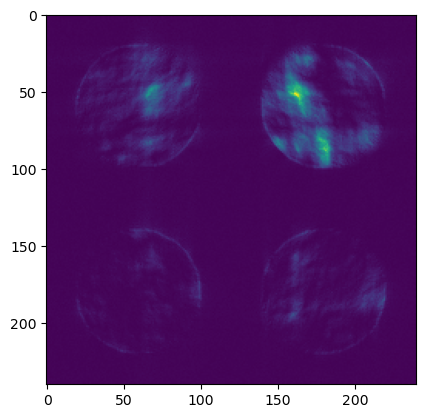

In [56]:
with torch.no_grad():
    Image = wfs.Propagator(phaseGT, pupilGT)

print(f'Image shape = {Image.shape}')

plt.imshow(Image[4].cpu())

In [ ]:
## You can see how the wavefronts move given the wind
n_iter = 100
for i in range(n_iter):
    phaseGT,pupilGT,modes,_,_,_,wind,_ = dataset[i]
    with torch.no_grad():
        Image = wfs.Propagator(phaseGT, pupilGT)
    # Clear previous output (without flickering)
    clear_output(wait=True)

    phases = phaseGT[:4].cpu()
    wfs_frames = Image[:4].cpu()
    

    main_pupil = dataset.pupil.cpu()

    num_frames = phases.shape[0]

    # Create subplots: 1 row, num_frames columns
    fig, axes = plt.subplots(2, num_frames, figsize=(3*num_frames, 6))
    
    # Ensure axes is iterable if num_frames = 1
    if num_frames == 1:
        axes = [axes]

    for j, frame in enumerate(phases):
        axes[0,j].imshow(frame, cmap='gray')
        axes[0,j].set_title(f"Phase {j+1}")
        axes[0,j].axis('off')
        axes[1,j].imshow(wfs_frames[j], cmap='gray')
        axes[1,j].set_title(f"WFS frame {j+1}")
        axes[1,j].axis('off')

    # Display the frame
    display(plt.gcf())
    
    # Pause so you can see the frame (adjust as needed)
    time.sleep(0.01)

    # Close the figure to prevent memory buildup
    plt.close()

preprocessed_frames shape = torch.Size([16, 4, 42, 42])


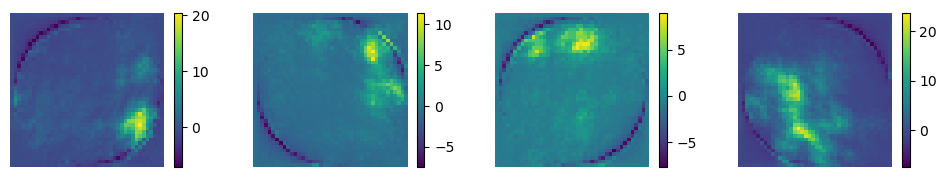

In [ ]:
image_index = 4

preprocessed_frames = framePreprocessor.ProcessFrame(Image)
print(f'preprocessed_frames shape = {preprocessed_frames.shape}')

fig, ax = plt.subplots(1, preprocessed_frames.shape[1], figsize = (12,2))
for i, pupil in enumerate(preprocessed_frames[image_index].cpu().detach()):
    im = ax[i].imshow(pupil)
    ax[i].axis('off')
    fig.colorbar(im, ax=ax[i])